# Task 5

In [1]:
import pandas as pd

### data read/load

In [7]:
data = pd.read_csv("Telco_Customer_Churn_Dataset.csv")

In [9]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors='coerce')

In [10]:
data["TotalCharges"].fillna(data["TotalCharges"].mean(), inplace=True)

C:\Users\sonuk\AppData\Local\Temp\ipykernel_22016\688485799.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data["TotalCharges"].fillna(data["TotalCharges"].mean(), inplace=True)


0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [14]:
data.drop_duplicates(inplace=True)

In [11]:
data.columns = data.columns.str.lower()
data.columns = data.columns.str.replace(" ", "_")

In [20]:
data["churn"] = data["churn"].map({"Yes":1, "No":0})

In [21]:
bins = [0, 12, 36, 100]
labels = ["0-12", "13-36", "37+"]

data["tenure_group"] = pd.cut(data["tenure"], bins=bins, labels=labels)

### 1. Grouping by Tenure

In [22]:
print(data.groupby("tenure_group")[["monthlycharges","churn"]].mean())

              monthlycharges     churn
tenure_group                          
0-12               56.172023  0.476782
13-36              63.248195  0.255388
37+                72.008730  0.119294


### 2. Gender vs Churn

In [23]:
print(data.groupby("gender")["churn"].mean())

gender
Female    0.269209
Male      0.261603
Name: churn, dtype: float64


### 3. Senior Citizen vs Churn

In [24]:
print(data.groupby("seniorcitizen")["churn"].mean())

seniorcitizen
0    0.236062
1    0.416813
Name: churn, dtype: float64


### 4. Payment Method vs Churn

In [25]:
print(data.groupby("paymentmethod")["churn"].mean())

paymentmethod
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Electronic check             0.452854
Mailed check                 0.191067
Name: churn, dtype: float64


### 5. Contract vs Churn

In [26]:
print(data.groupby("contract")["churn"].mean())

contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: churn, dtype: float64


### 6. Trend Visualization

In [31]:
import matplotlib.pyplot as plt

In [32]:
import seaborn as sns

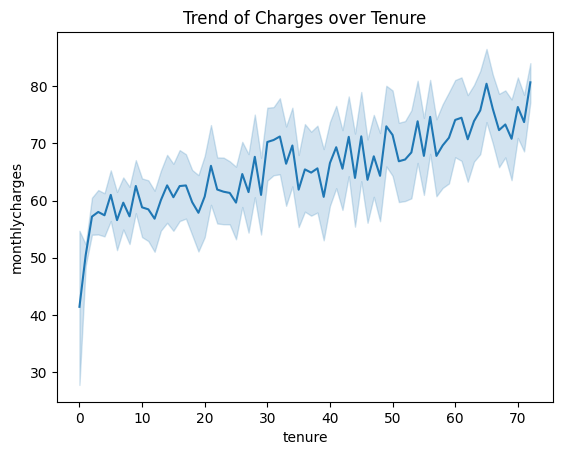

In [34]:
sns.lineplot(x="tenure", y="monthlycharges", data=data)
plt.title("Trend of Charges over Tenure")
plt.show()